In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('Titanic-Dataset.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
data.shape

(891, 12)

In [7]:
data.size

10692

In [8]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [9]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

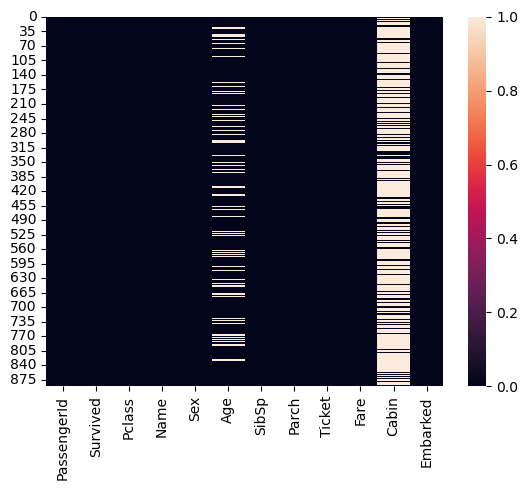

In [10]:
sns.heatmap(data.isnull())

In [11]:
data["Age"]=data["Age"].fillna(data["Age"].median())

In [12]:
data['Cabin']=data['Cabin'].fillna('unknown')

In [13]:
data['Embarked']=data['Embarked'].fillna(data['Embarked'].mode()[0])

In [14]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [17]:
data['Age'].mean()

np.float64(29.36158249158249)

In [18]:
data.groupby('Sex')['Age'].mean()

Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64

In [19]:
data['Fare'].skew()

np.float64(4.787316519674893)

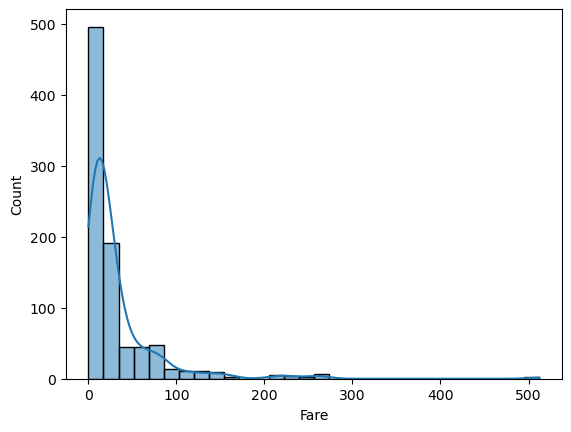

In [20]:
sns.histplot(data['Fare'],bins=30,kde=True)
plt.show()


In [21]:
data['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

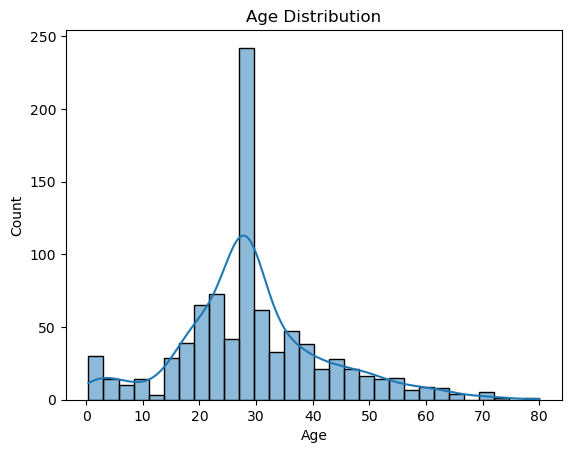

In [22]:
sns.histplot(data['Age'], bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

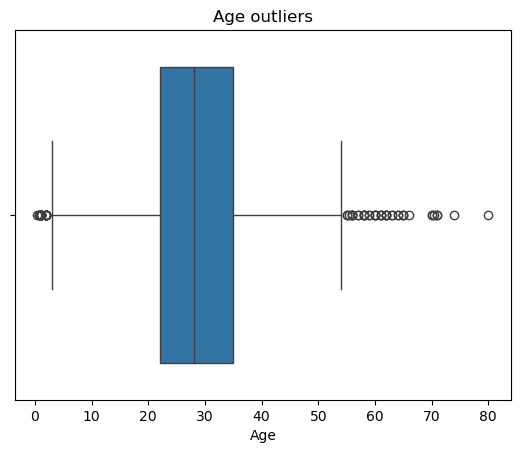

In [23]:
sns.boxplot(x=data['Age'])
plt.title('Age outliers')
plt.show()

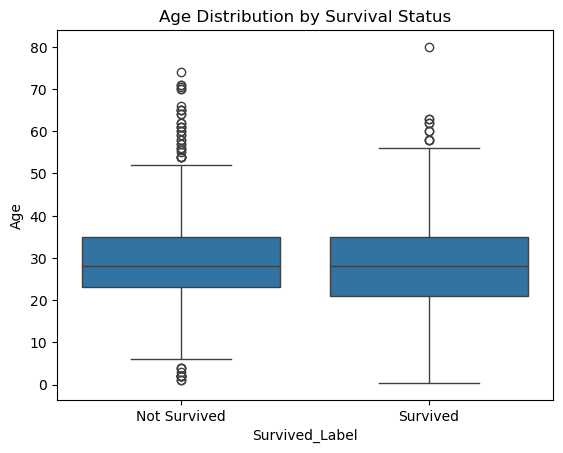

In [24]:
data['Survived_Label'] = data['Survived'].map({0: 'Not Survived', 1: 'Survived'})

sns.boxplot(x='Survived_Label', y='Age', data=data)
plt.title('Age Distribution by Survival Status')
plt.show()

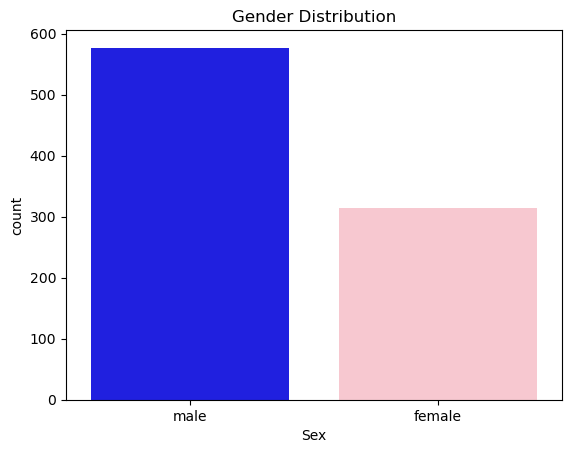

In [25]:
sns.countplot(
    x='Sex',
    hue='Sex',
    data=data,
    palette={'female': 'pink', 'male': 'blue'},
    legend=False
)

plt.title("Gender Distribution")
plt.show()

In [26]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [27]:
data.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

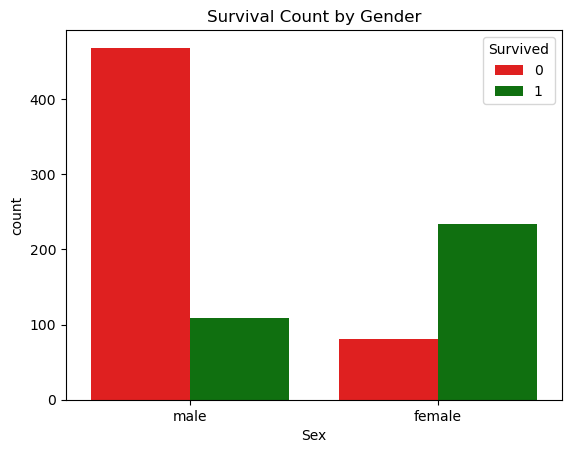

In [28]:
sns.countplot(x='Sex',hue='Survived',data=data,palette={0: 'red', 1: 'green'})
plt.title('Survival Count by Gender')
plt.show()


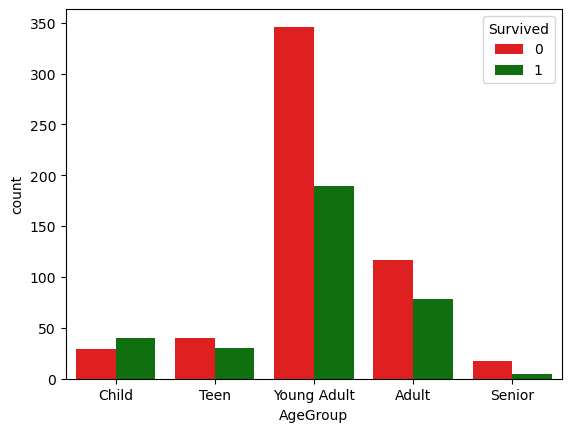

In [29]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels)
sns.countplot(x='AgeGroup', hue='Survived', data=data,palette={0: 'red', 1: 'green'})
plt.show()

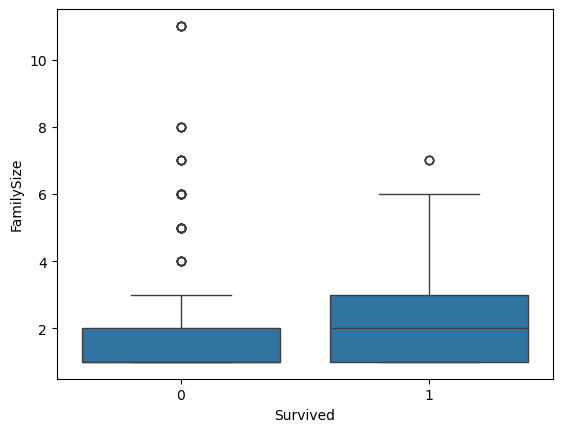

In [30]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
sns.boxplot(x='Survived', y='FamilySize', data=data)
plt.show()

In [31]:
data.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

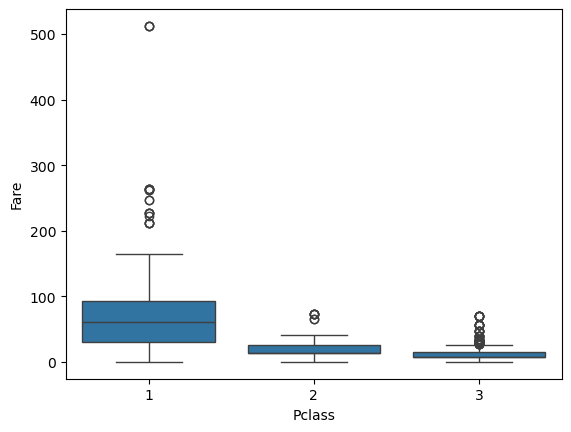

In [32]:
sns.boxplot(x='Pclass', y='Fare', data=data)
plt.show()

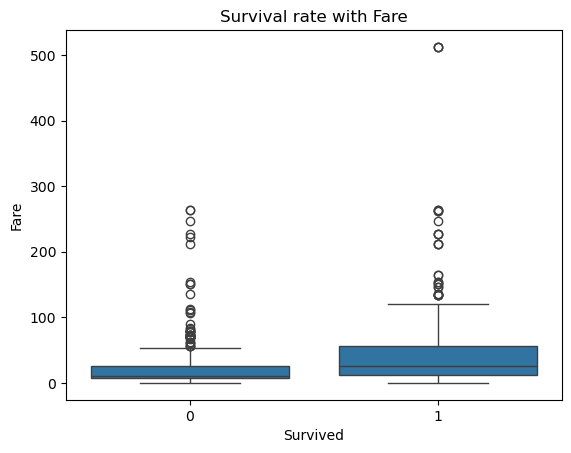

In [33]:
sns.boxplot(y=data['Fare'],x=data['Survived'],data=data)
plt.title('Survival rate with Fare')
plt.show()

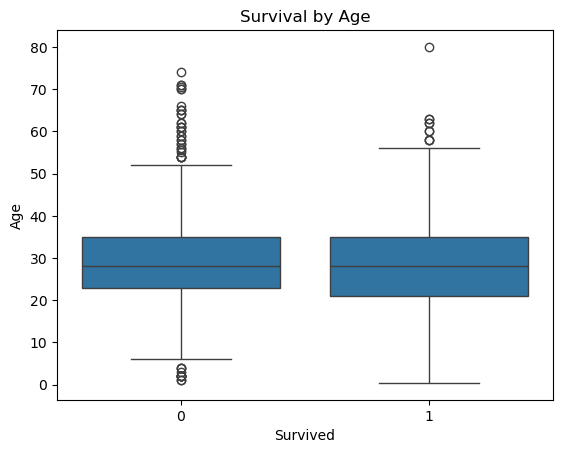

In [34]:
sns.boxplot(y=data["Age"],x=data['Survived'],data=data)
plt.title('Survival by Age')
plt.show()

In [35]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived_Label,AgeGroup,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,unknown,S,Not Survived,Young Adult,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Survived,Adult,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,unknown,S,Survived,Young Adult,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Survived,Young Adult,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,unknown,S,Not Survived,Young Adult,1


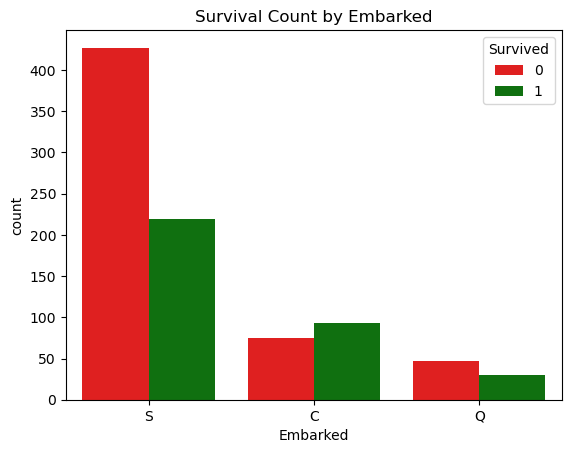

In [36]:
sns.countplot(x=data["Embarked"],hue=data['Survived'],data=data,palette={0: 'red', 1: 'green'})
plt.title('Survival Count by Embarked')
plt.show()

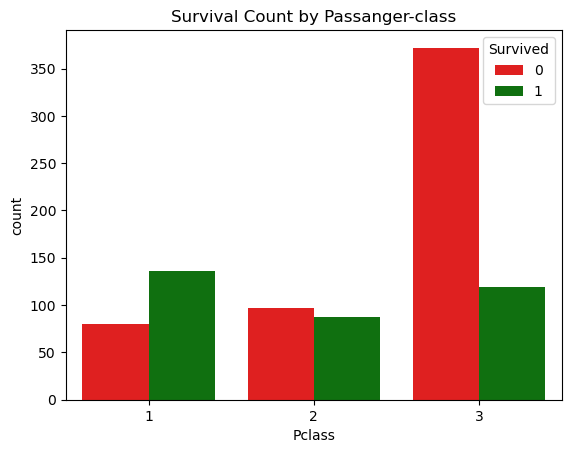

In [37]:
sns.countplot(x=data["Pclass"],hue=data['Survived'],data=data,palette={0: 'red', 1: 'green'})
plt.title('Survival Count by Passanger-class')
plt.show()

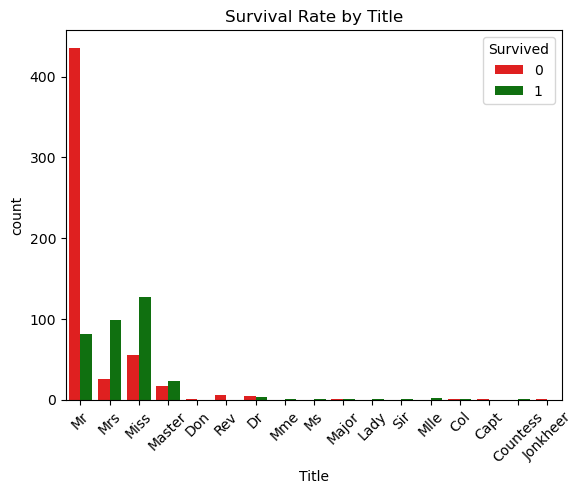

In [38]:
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
data['Title'].value_counts()
sns.countplot(x='Title', hue='Survived', data=data,palette={0: 'red', 1: 'green'})
plt.xticks(rotation=45)
plt.title("Survival Rate by Title")
plt.show()

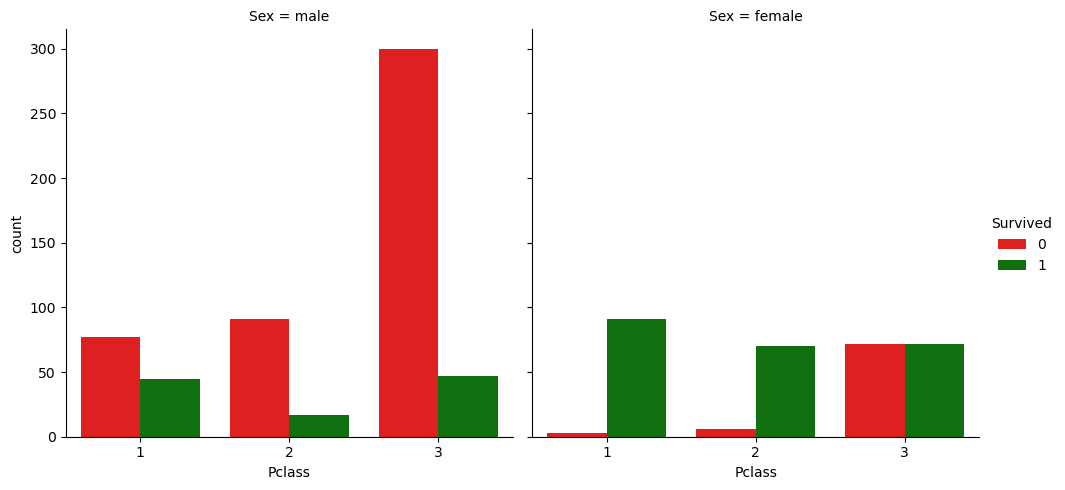

In [39]:
sns.catplot(x='Pclass', hue='Survived', col='Sex', kind='count', data=data,palette={0: 'red', 1: 'green'})
plt.show()

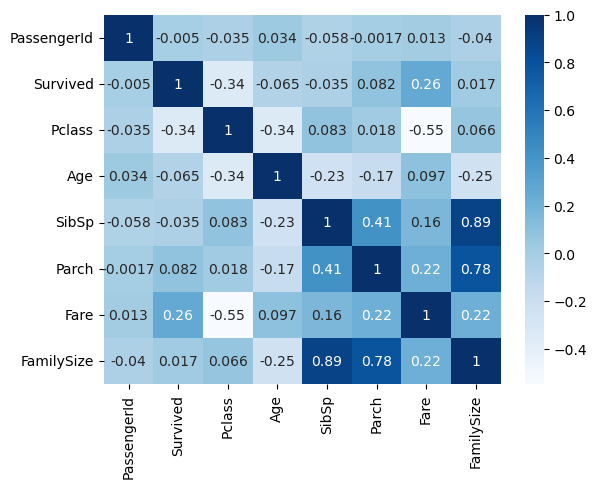

In [40]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='Blues')
plt.show()